# Handscan unhealthy waveform images

Browse raw waveform `.h5` samples and archive **unhealthy** ones with enough metadata to reload the exact image later.

**Kernel:** select **`env`** (`/exp/sbnd/app/users/munjung/env`).

**H5 layout** (from `wvfm2h5.py`):
- Each run lives in `{H5_ROOT}/{run_id}_{subrun}/`
- Files are named `g4-raw-{tpc}_{file_idx}.h5` (10 events per file by default)
- Event `N` is stored at `/{N}/raw` with shape `(5638, 3427)` (wires × ticks)

**Workflow**
1. Run **Build sample index** once (or after adding new H5 files).
2. Run **Launch scanner** and step through images.
3. Click **Unhealthy** (or press `u`) to save metadata + a short note, then advance.
4. Click **Skip** (or press `s`) for healthy images.
5. Use **Review archive** to inspect notes and assign categories for grouping.

Archives are written under `ARCHIVE_DIR`:
- `unhealthy.jsonl` — one JSON record per flagged sample
- `scan_state.json` — resume position
- `skipped.jsonl` — optional log of healthy skips (off by default)

In [5]:
from __future__ import annotations

import gc
import json
import re
from datetime import datetime, timezone
from pathlib import Path

import h5py
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# ── Configure ────────────────────────────────────────────────────────────────
H5_ROOT = Path(
    # "/pnfs/sbnd/scratch/users/munjung/v10_06_00/raw-SBND_DATA_InTimeCosmics_offbeamlight/h5"
    "/pnfs/sbnd/scratch/users/munjung/v10_06_00/data_MCP2025B_CrossingMuon_FullRun1_AfterLight_8_crossingmuon/h5"
)
ARCHIVE_DIR = Path("handscan_archives/offbeamlight_v10_06_00")
ARCHIVE_DIR.mkdir(parents=True, exist_ok=True)

UNHEALTHY_PATH = ARCHIVE_DIR / "unhealthy.jsonl"
SKIPPED_PATH = ARCHIVE_DIR / "skipped.jsonl"
STATE_PATH = ARCHIVE_DIR / "scan_state.json"
INDEX_PATH = ARCHIVE_DIR / "sample_index.json"

LOG_HEALTHY_SKIPS = False  # set True to append every skip to skipped.jsonl

# Display (matches inspect_samples.ipynb)
IMSHOW_KW = dict(aspect="auto", cmap="bwr", origin="lower", vmin=-15, vmax=15)
PLANE_EDGES = [1984, 3968]  # wire indices within one TPC slice
FIG_SIZE = (22, 4)
GC_EVERY = 10  # periodic gc while scanning

H5_NAME_RE = re.compile(r"g4-raw-(?P<tpc>\d+)_(?P<file_idx>\d+)\.h5$")
RUN_DIR_RE = re.compile(r"(?P<run_id>\d+)_(?P<subrun>\d+)$")

plt.rcParams["figure.dpi"] = 100


## Build sample index

In [6]:
def parse_h5_name(name: str) -> dict:
    m = H5_NAME_RE.match(name)
    if not m:
        raise ValueError(f"Unexpected H5 filename: {name}")
    return {"tpc": int(m.group("tpc")), "file_idx": int(m.group("file_idx"))}


def parse_run_dir(name: str) -> dict:
    m = RUN_DIR_RE.match(name)
    if not m:
        return {"run_id": name, "subrun": None}
    return {"run_id": m.group("run_id"), "subrun": int(m.group("subrun"))}


def make_sample_id(run_dir: str, h5_filename: str, event_idx: int) -> str:
    return f"{run_dir}/{h5_filename}:{event_idx}"


def build_sample_index(h5_root: Path) -> tuple[list[dict], list[str]]:
    """Return (samples, bad_files)."""
    samples: list[dict] = []
    bad_files: list[str] = []
    global_idx = 0

    for run_path in sorted(h5_root.iterdir()):
        if not run_path.is_dir():
            continue
        run_dir = run_path.name
        run_meta = parse_run_dir(run_dir)

        for h5_path in sorted(run_path.glob("*raw-0*.h5")):
            try:
                with h5py.File(h5_path, "r") as hf:
                    event_keys = sorted(hf.keys(), key=int)
                    h5_meta = parse_h5_name(h5_path.name)
                    for event_idx in map(int, event_keys):
                        shape = tuple(int(x) for x in hf[f"{event_idx}/raw"].shape)
                        samples.append(
                            {
                                "global_idx": global_idx,
                                "sample_id": make_sample_id(run_dir, h5_path.name, event_idx),
                                "h5_path": str(h5_path),
                                "run_dir": run_dir,
                                "run_id": run_meta["run_id"],
                                "subrun": run_meta["subrun"],
                                "h5_filename": h5_path.name,
                                "tpc": h5_meta["tpc"],
                                "file_idx": h5_meta["file_idx"],
                                "event_idx": event_idx,
                                "data_shape": list(shape),
                                "dataset_path": f"/{event_idx}/raw",
                            }
                        )
                        global_idx += 1
            except OSError as exc:
                bad_files.append(f"{h5_path}: {exc}")

    return samples, bad_files


samples, bad_files = build_sample_index(H5_ROOT)
INDEX_PATH.write_text(json.dumps(samples, indent=2))

print(f"Indexed {len(samples)} events from {H5_ROOT}")
print(f"Saved index → {INDEX_PATH}")
if bad_files:
    print(f"\nSkipped {len(bad_files)} unreadable H5 file(s):")
    for line in bad_files:
        print(f"  {line}")

Indexed 8480 events from /pnfs/sbnd/scratch/users/munjung/v10_06_00/data_MCP2025B_CrossingMuon_FullRun1_AfterLight_8_crossingmuon/h5
Saved index → handscan_archives/offbeamlight_v10_06_00/sample_index.json


## Archive helpers

In [7]:
def utc_now() -> str:
    return datetime.now(timezone.utc).replace(microsecond=0).isoformat()


def load_jsonl(path: Path) -> list[dict]:
    if not path.exists():
        return []
    rows = []
    for line in path.read_text().splitlines():
        line = line.strip()
        if line:
            rows.append(json.loads(line))
    return rows


def append_jsonl(path: Path, record: dict) -> None:
    with path.open("a") as fh:
        fh.write(json.dumps(record, sort_keys=True) + "\n")


def load_scan_state() -> dict:
    if STATE_PATH.exists():
        return json.loads(STATE_PATH.read_text())
    return {"next_global_idx": 0, "updated_at": None}


def save_scan_state(next_global_idx: int) -> None:
    STATE_PATH.write_text(
        json.dumps({"next_global_idx": next_global_idx, "updated_at": utc_now()}, indent=2)
    )


def load_waveform(sample: dict) -> np.ndarray:
    """Load event as float32 ticks×wires; closes the H5 file immediately."""
    with h5py.File(sample["h5_path"], "r") as hf:
        arr = np.asarray(hf[f"{sample['event_idx']}/raw"], dtype=np.float32)
    return arr.T  # (ticks, wires)


def reload_from_record(record: dict) -> np.ndarray:
    with h5py.File(record["h5_path"], "r") as hf:
        arr = np.asarray(hf[f"{record['event_idx']}/raw"], dtype=np.float32)
    return arr.T


def flagged_sample_ids() -> set[str]:
    return {row["sample_id"] for row in load_jsonl(UNHEALTHY_PATH)}


Resume index: 1919  |  archive: handscan_archives/offbeamlight_v10_06_00/unhealthy.jsonl
Click the plot once, then use u/s/b/j keys.


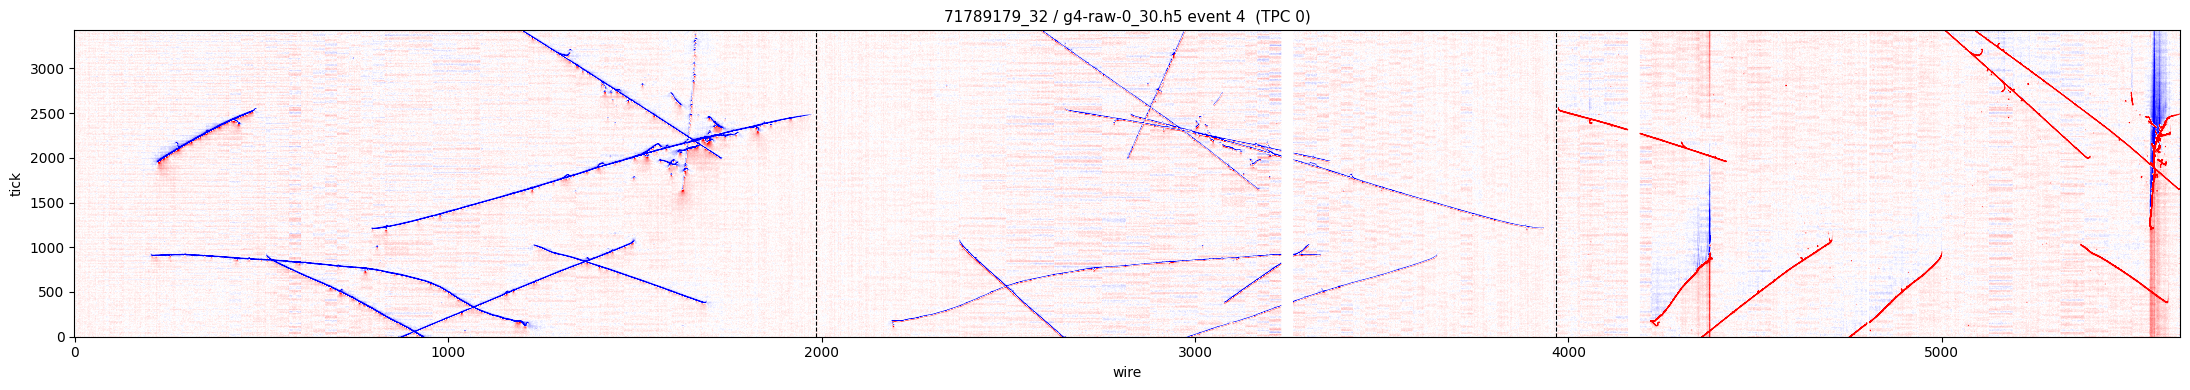

In [8]:
class HandScanner:
    def __init__(self, samples: list[dict], start_idx: int | None = None):
        if not samples:
            raise ValueError("Sample index is empty. Run 'Build sample index' first.")
        self.samples = samples
        state = load_scan_state()
        self.idx = start_idx if start_idx is not None else int(state.get("next_global_idx", 0))
        self.idx = max(0, min(self.idx, len(self.samples) - 1))
        self.flagged = flagged_sample_ids()
        self._steps = 0
        self._im = None

        self.fig, self.ax = plt.subplots(figsize=FIG_SIZE)
        self.fig.canvas.mpl_connect("key_press_event", self._on_key)
        self.plot_out = widgets.Output()

        self.note_box = widgets.Textarea(
            placeholder="What is unhealthy? e.g. diagonal streaks, blips in plane 1, shadow band …",
            layout=widgets.Layout(width="95%", height="70px"),
        )
        self.category_box = widgets.Text(
            placeholder="Optional category (can fill in later during review)",
            layout=widgets.Layout(width="50%"),
        )
        self.jump_box = widgets.IntText(
            value=self.idx, description="Go to idx:", layout=widgets.Layout(width="220px")
        )
        self.status = widgets.HTML()

        self.btn_unhealthy = widgets.Button(
            description="Unhealthy (u)", button_style="danger", icon="exclamation-triangle"
        )
        self.btn_skip = widgets.Button(description="Skip (s)", button_style="success", icon="check")
        self.btn_back = widgets.Button(description="Back (b)", icon="arrow-left")
        self.btn_jump = widgets.Button(description="Jump (j)", icon="forward")

        self.btn_unhealthy.on_click(lambda _: self.mark_unhealthy())
        self.btn_skip.on_click(lambda _: self.mark_skip())
        self.btn_back.on_click(lambda _: self.step(-1))
        self.btn_jump.on_click(lambda _: self.jump())

        controls = widgets.HBox(
            [self.btn_unhealthy, self.btn_skip, self.btn_back, self.btn_jump, self.jump_box]
        )
        self.ui = widgets.VBox(
            [self.status, self.plot_out, self.note_box, self.category_box, controls]
        )
        self._render()

    def _on_key(self, event):
        key = (event.key or "").lower()
        if key == "u":
            self.mark_unhealthy()
        elif key == "s":
            self.mark_skip()
        elif key == "b":
            self.step(-1)
        elif key == "j":
            self.jump()

    @property
    def sample(self) -> dict:
        return self.samples[self.idx]

    def _maybe_gc(self) -> None:
        self._steps += 1
        if self._steps % GC_EVERY == 0:
            gc.collect()

    def _render(self) -> None:
        s = self.sample
        data = load_waveform(s)
        flagged = (
            "<b style='color:#c0392b'>FLAGGED</b>" if s["sample_id"] in self.flagged else ""
        )
        self.status.value = (
            f"<b>[{self.idx + 1}/{len(self.samples)}]</b> "
            f"global_idx={s['global_idx']} &nbsp;|&nbsp; "
            f"<code>{s['sample_id']}</code> &nbsp;|&nbsp; "
            f"tpc={s['tpc']} file={s['file_idx']} evt={s['event_idx']} "
            f"run={s['run_id']} subrun={s['subrun']} {flagged}"
        )
        self.jump_box.value = self.idx

        if self._im is None:
            self._im = self.ax.imshow(data, **IMSHOW_KW)
            for edge in PLANE_EDGES:
                self.ax.axvline(edge, color="k", linestyle="--", linewidth=0.8)
            self.ax.set_xlabel("wire")
            self.ax.set_ylabel("tick")
        else:
            self._im.set_data(data)
            self._im.set_clim(IMSHOW_KW["vmin"], IMSHOW_KW["vmax"])

        self.ax.set_title(
            f"{s['run_dir']} / {s['h5_filename']} event {s['event_idx']}  (TPC {s['tpc']})",
            fontsize=11,
        )
        self.fig.tight_layout()

        with self.plot_out:
            self.plot_out.clear_output(wait=True)
            display(self.fig)

        del data
        self._maybe_gc()

    def close(self) -> None:
        if self.fig is not None:
            plt.close(self.fig)
            self.fig = None
            self.ax = None
            self._im = None
        gc.collect()

    def step(self, delta: int) -> None:
        self.idx = max(0, min(self.idx + delta, len(self.samples) - 1))
        save_scan_state(self.idx)
        self._render()

    def jump(self) -> None:
        self.idx = max(0, min(int(self.jump_box.value), len(self.samples) - 1))
        save_scan_state(self.idx)
        self._render()

    def mark_unhealthy(self) -> None:
        note = self.note_box.value.strip()
        if not note:
            self.status.value += (
                " &nbsp; <span style='color:#c0392b'>Add a note before flagging unhealthy.</span>"
            )
            return

        s = self.sample
        record = {
            **s,
            "note": note,
            "category": self.category_box.value.strip(),
            "flagged_at": utc_now(),
        }
        append_jsonl(UNHEALTHY_PATH, record)
        self.flagged.add(s["sample_id"])

        self.note_box.value = ""
        self.category_box.value = ""
        self.step(+1)

    def mark_skip(self) -> None:
        if LOG_HEALTHY_SKIPS:
            s = self.sample
            append_jsonl(SKIPPED_PATH, {**s, "skipped_at": utc_now()})
        self.note_box.value = ""
        self.step(+1)


# Tear down any previous scanner from this kernel before opening a new one
if "scanner" in globals() and hasattr(scanner, "close"):
    scanner.close()
plt.close("all")
gc.collect()

# Reload index from disk if you already built it in a previous session
if INDEX_PATH.exists():
    samples = json.loads(INDEX_PATH.read_text())
else:
    samples, _ = build_sample_index(H5_ROOT)

scanner = HandScanner(samples)
display(scanner.ui)
print(
    f"Resume index: {load_scan_state()['next_global_idx']}  |  archive: {UNHEALTHY_PATH}\n"
    f"Click the plot once, then use u/s/b/j keys."
)


## Review archive

Inspect flagged samples, edit categories, and group by note keywords.

In [ ]:
rows = load_jsonl(UNHEALTHY_PATH)
if not rows:
    print(f"No unhealthy samples yet → {UNHEALTHY_PATH}")
else:
    df = pd.DataFrame(rows)
    cols = [
        "sample_id", "note", "category", "flagged_at",
        "run_dir", "h5_filename", "event_idx", "tpc", "file_idx", "h5_path",
    ]
    cols = [c for c in cols if c in df.columns] + [c for c in df.columns if c not in cols]
    display(df[cols])
    print(f"\n{len(df)} unhealthy sample(s)")

In [ ]:
# Group by category (after you assign them) or by note text
if rows:
    if "category" in df.columns and df["category"].astype(str).str.strip().ne("").any():
        print("By category:")
        print(df.groupby("category", dropna=False)["sample_id"].apply(list).to_string())
    print("\nBy note (exact match):")
    print(df.groupby("note", dropna=False)["sample_id"].apply(list).to_string())

In [ ]:
# for ridx, r in enumerate(rows):
#     print(ridx, r['note'])

In [ ]:
# Reload a flagged sample by sample_id (edit the string below)
TARGET = rows[24]["sample_id"] if rows else "86414724_42/g4-raw-0_10.h5:3"
rec = next(r for r in rows if r["sample_id"] == TARGET)
data = reload_from_record(rec)

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.imshow(data, **IMSHOW_KW)
for edge in PLANE_EDGES:
    ax.axvline(edge, color="k", linestyle="--", linewidth=0.8)
ax.set_title(f"{rec['sample_id']} — {rec.get('note', '')}")
plt.show()

In [ ]:
# Bulk-assign categories from a mapping {sample_id: category}
# Re-run after editing CATEGORY_MAP, then re-run the review cells above.
CATEGORY_MAP: dict[str, str] = {
    # "86414724_42/g4-raw-0_10.h5:3": "blips",
}

if CATEGORY_MAP and rows:
    updated = []
    for rec in rows:
        rec = dict(rec)
        if rec["sample_id"] in CATEGORY_MAP:
            rec["category"] = CATEGORY_MAP[rec["sample_id"]]
        updated.append(rec)
    UNHEALTHY_PATH.write_text("\n".join(json.dumps(r, sort_keys=True) for r in updated) + "\n")
    print(f"Updated categories in {UNHEALTHY_PATH}")

In [ ]:
## Browse by note

# Show up to **N** flagged events whose note matches `NOTE_QUERY` (exact match by default; set `SUBSTRING=True` for contains).

In [ ]:
# Configure
NOTE_QUERY = "strong coherent noise"  # exact note text, or substring if SUBSTRING=True
N = 20
SUBSTRING = False  # True → match notes that contain NOTE_QUERY

rows = load_jsonl(UNHEALTHY_PATH)
if SUBSTRING:
    matches = [r for r in rows if NOTE_QUERY.lower() in str(r.get("note", "")).lower()]
else:
    matches = [r for r in rows if str(r.get("note", "")).strip() == NOTE_QUERY.strip()]

print(f"{len(matches)} match(es) for note={NOTE_QUERY!r} (showing up to {N})")
if not matches:
    print("Available notes:")
    for note, count in sorted(
        ((n, sum(1 for r in rows if r.get("note") == n)) for n in {r.get("note") for r in rows}),
        key=lambda x: (-x[1], str(x[0])),
    ):
        print(f"  [{count:3d}] {note!r}")
else:
    for i, rec in enumerate(matches[:N]):
        data = reload_from_record(rec)
        fig, ax = plt.subplots(figsize=FIG_SIZE)
        ax.imshow(data, **IMSHOW_KW)
        for edge in PLANE_EDGES:
            ax.axvline(edge, color="k", linestyle="--", linewidth=0.8)
        ax.set_title(
            f"[{i + 1}/{min(N, len(matches))}] {rec['sample_id']} — {rec.get('note', '')}"
        )
        plt.show()
        plt.close(fig)
